In [1]:
from dataclasses import replace

import pandas as pd
import numpy as np
from IPython.core.pylabtools import figsize
from pandas.core.dtypes.missing import isnull

In [2]:
class BaseDataHandler:
    def __init__(self, file_path):
        self.file_path = file_path
        self.df = None
        self.load_data()

# Superstore Sales & Profitability Analysis
**Business Scenario:** A multinational retail company wants an automated analytical solution to monitor sales, profitability, customer behavior, and operational performance.

## Step 1: Data Loading
In this step, we build a `DataLoader` class to import the dataset securely and display its metadata and structure using Exception Handling.

In [3]:
class DataLoader(BaseDataHandler):
    def load_data(self):
        try :
            print("Loading data... Please Wait.")
            self.df = pd.read_excel(self.file_path,sheet_name = "Orders")
            print("Data loaded successfully! ✅")

            print("----- Dataset Info -----")
            self.df.info()
            print("\n----- Dataset Shape -----")
            print(f"Rows: {self.df.shape[0]}, Columns : {self.df.shape[1]}")

        except FileNotFoundError:
                print(f"Error : the file '{self.file_path}' was not found. Please check the path and try again.")
        except Exception as e:
                print(f"An unexpected error occurred while loading the data. {e}")

In [4]:
file_name = "Sample - Superstore 2019.xls"
analyzer = DataLoader(file_name)

Loading data... Please Wait.
Data loaded successfully! ✅
----- Dataset Info -----
<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          9994 non-null   int64         
 1   Order ID        9994 non-null   str           
 2   Order Date      9994 non-null   datetime64[us]
 3   Ship Date       9994 non-null   datetime64[us]
 4   Ship Mode       9994 non-null   str           
 5   Customer ID     9994 non-null   str           
 6   Customer Name   9994 non-null   str           
 7   Segment         9994 non-null   str           
 8   Country/Region  9994 non-null   str           
 9   City            9994 non-null   str           
 10  State           9994 non-null   str           
 11  Postal Code     9983 non-null   float64       
 12  Region          9994 non-null   str           
 13  Product ID      9994 non-null   str  

## Step 2: Advanced Data Cleaning
The `DataCleaner` class is responsible for standardizing column names, removing duplicates, handling missing values, and dealing with outliers using the IQR capping method to ensure data integrity.

In [5]:
class DataCleaner:
    def __init__(self, dataframe):
        # Take a copy to work on that
        self.df = dataframe.copy()

    def clean_data(self):
        print("----- Starting Data Cleaning -----")

        # Standardize column names
        self.df.columns = self.df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('-', '_')
        print("Column names standardized.")

        # Handle Duplicates
        initial_rows = len(self.df)
        self.df = self.df.drop_duplicates()
        duplicates_removed = initial_rows - len(self.df)
        print(f"Removed {duplicates_removed} duplicate rows.")

        # Handle Missing Values
        missing_postal = self.df['postal_code'].isnull().sum()
        if missing_postal > 0:
            self.df['postal_code'] = self.df['postal_code'].fillna(5401)
            print(f"Filled {missing_postal} missing values in 'postal_code'.")

        # Correct Data types
        self.df['postal_code'] = self.df['postal_code'].astype(int)

        # Handel Outliers using IQR
        cols_for_outliers = ["sales", "profit"]
        for col in cols_for_outliers:
            Q1 = self.df[col].quantile(0.25)
            Q3 = self.df[col].quantile(0.75)
            IQR = Q3 - Q1

            # LOWER & UPPER
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            self.df[col] = np.clip(self.df[col], lower_bound, upper_bound)

        print("Outliers handled successfully using IQR capping! ✅")
        print("Data cleaning completed! ✅\n")
        return self.df

In [6]:
cleaner = DataCleaner(analyzer.df)

cleaned_df = cleaner.clean_data()
print(cleaned_df.columns.tolist())

----- Starting Data Cleaning -----
Column names standardized.
Removed 0 duplicate rows.
Filled 11 missing values in 'postal_code'.
Outliers handled successfully using IQR capping! ✅
Data cleaning completed! ✅

['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'country/region', 'city', 'state', 'postal_code', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'quantity', 'discount', 'profit']


## Step 3: Feature Engineering
Here, we create new analytical columns to uncover deeper insights. The `FeatureEngineer` class adds `shipping_duration`, `profit_margin`, and groups sales into a `sales_performance` category.

In [7]:
class FeatureEngineer:
    def __init__(self,dataframe):
        self.df = dataframe.copy()

    def engineer_features(self):
        print("----- Starting Feature Engineering ----- ")

        # shipping Duration (Via Days)
        self.df["shipping_duration"] = (self.df["ship_date"] - self.df["order_date"]).dt.days

        # profit margin (%)
        self.df["profit_margin"] = (self.df["profit"] / self.df["sales"]) * 100

        # Sales Performance Category
        bins = [0, 50 ,200,float("inf")]
        labels = ["Low" , "Medium", "High"]
        self.df["sales_performance"] = pd.cut(self.df["sales"],bins=bins , labels = labels)

        print("Feature Engineering completed! ✅\n")
        return self.df

In [8]:
engineer = FeatureEngineer(cleaned_df)
final_df = engineer.engineer_features()

display(final_df[["order_id","shipping_duration","profit_margin", "sales_performance"]].head())

----- Starting Feature Engineering ----- 
Feature Engineering completed! ✅



,order_id,shipping_duration,profit_margin,sales_performance
0,CA-2018-152156,3,16.000000,High
1,CA-2018-152156,3,14.193750,High
2,CA-2018-138688,4,47.000000,Low
3,US-2017-108966,7,-7.961863,High
4,US-2017-108966,7,11.250000,Low


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

## Step 4: Exploratory Data Analysis (EDA) & Visualizations
The `EDA` class performs statistical analysis, correlation checks, and generates advanced visualizations to understand sales distributions, category performance, and trends over time.

In [10]:
class EDA:
    def __init__(self,dataframe):
        self.df = dataframe.copy()
        sns.set_theme(style = "whitegrid")

    def perform_statistical_analysis(self):
        print("----- Statistical Summary & Correlation -----")

        # DESCRIBE
        cols_to_describe = ["sales","profit","shipping_duration","profit_margin"]
        display(self.df[cols_to_describe].describe())

        # CORR
        numeric_df = self.df.select_dtypes(include = ["float64", "int64", "int32"])
        corr_matrix = numeric_df.corr()

        # Heatmap
        plt.figure(figsize=(10,6))
        sns.heatmap(corr_matrix, annot=True, cmap= "coolwarm", fmt = ".2f", linewidths= 0.5)
        plt.title("Correlation Matrix of Numeric Features", fontsize = 14 , fontweight = "bold")
        plt.savefig("Correlation Matrix of Numeric Features.png", bbox_inches='tight')
        plt.show()

    def generate_initial_visualizations(self):
        print("----- Generation Initial Visualizations ----- ")

        # Detect Outliers
        plt.figure(figsize=(10,5))
        sns.histplot(self.df["sales"],bins =60 ,kde = True, color = "blue")
        plt.title("Distribution of Sales",fontsize = 14 , fontweight = "bold")
        plt.savefig("Distribution of Sales.png", bbox_inches='tight')
        plt.show()

        # Total Sales of each Category
        plt.figure(figsize=(8,5))
        sns.barplot(x="category" , y= "sales" , data=self.df, estimator=sum, errorbar=None ,palette = "viridis", hue = "category" , legend = False)
        plt.title("total sales by Category",fontsize = 14 , fontweight = "bold")
        plt.ylabel("Total Sales ($)")
        plt.savefig("total sales by Category.png", bbox_inches='tight')
        plt.show()

    def generate_advanced_visualizations(self):
        print("----- Generation Advanced Visualizations -----")

        # TOTAL PROFIT FOR EACH CATEGORY
        plt.figure(figsize=(8,5))
        sns.barplot(x="category", y="profit", data=self.df, estimator=sum, errorbar=None ,palette="RdYlGn", hue = "category" , legend = False)
        plt.title("Total Profit by Category", fontsize = 14, fontweight = "bold" )
        plt.ylabel("Total Profit ($)")
        plt.savefig("Total Profit by Category.png", bbox_inches='tight')
        plt.show()

        # SALES & PROFIT FOR EACH REGION
        fig , axes = plt.subplots(1,2,figsize=(15,5))
        sns.barplot(x="region", y="sales", data=self.df, estimator=sum, errorbar=None,ax=axes[0], palette="Blues", hue = "region" , legend = False)
        axes[0].set_title("Total Sales by Region")

        sns.barplot(x="region", y="profit", data=self.df, estimator=sum, errorbar=None,ax=axes[1], palette="Greens", hue = "region" , legend = False)
        axes[1].set_title("Total Profit by Region")
        plt.tight_layout()
        plt.savefig("SALES & PROFIT FOR EACH REGION.png", bbox_inches='tight')
        plt.show()

        # TOP 10 PRODUCTS IN SALES
        plt.figure(figsize=(10,6))
        top_10_products = self.df.groupby("product_name")['sales'].sum().nlargest(10).reset_index()
        sns.barplot(y='product_name', x='sales', data=top_10_products, palette='magma', hue='product_name', legend=False)
        plt.title("Top 10 Products by Sales", fontsize=14, fontweight='bold')
        plt.xlabel("Total Sales ($)")
        plt.ylabel("")
        plt.savefig("Top 10 Products by Sales.png", bbox_inches='tight')
        plt.show()

        # IMPACT OF DISCOUNT ON PROFIT MARGIN
        plt.figure(figsize=(8,5))
        sns.lineplot(x='discount', y='profit_margin', data=self.df, color='red', marker='o')
        plt.title("Impact of Discount on Profit Margin", fontsize=14, fontweight='bold')
        plt.ylabel("Profit Margin (%)")
        plt.xlabel("Discount Rate")
        plt.savefig("Impact of Discount on Profit Margin.png", bbox_inches='tight')
        plt.show()

    def generate_final_visualizations(self):
        print("----- Generating Final Visualizations -----")
        # Total Profit by Sub-Category
        plt.figure(figsize=(12, 7))
        subcat_profit = self.df.groupby('sub_category')['profit'].sum().sort_values(ascending=False).reset_index()
        sns.barplot(x='profit', y='sub_category', data=subcat_profit, palette='coolwarm', hue='sub_category', legend=False)
        plt.title("Total Profit by Sub-Category (Profit Makers vs. Loss Makers)", fontsize=14, fontweight='bold')
        plt.xlabel("Total Profit ($)")
        plt.ylabel("")
        plt.tight_layout()
        plt.savefig("Total Profit by Sub-Category.png", bbox_inches='tight')
        plt.show()

        # Trend Analysis: Sales over time
        plt.figure(figsize=(12, 5))
        trend_data = self.df.set_index('order_date').resample('ME')['sales'].sum().reset_index()
        sns.lineplot(x='order_date', y='sales', data=trend_data, color='purple', marker='o')
        plt.title("Sales Trend Over Time", fontsize=14, fontweight='bold')
        plt.xlabel("Order Date")
        plt.ylabel("Total Sales")
        plt.savefig("Sales Trend Over Time.png", bbox_inches='tight')
        plt.show()


        # Average Profit by Sales Performance
        plt.figure(figsize=(8, 5))
        sns.barplot(x='sales_performance', y='profit', data=self.df, palette='viridis', errorbar=None, hue='sales_performance', legend=False, dodge=False)
        plt.title("Average Profit by Sales Performance (Low vs Medium vs High)", fontsize=14, fontweight='bold')
        plt.xlabel("Sales Size (Performance Category)")
        plt.ylabel("Average Profit ($)")
        plt.savefig("Average Profit by Sales Performance.png", bbox_inches='tight')
        plt.show()


        # Shipping Time Distribution by Shipping Mode
        plt.figure(figsize=(10, 6))
        sns.boxplot(x='ship_mode', y='shipping_duration', data=self.df, palette='pastel', hue='ship_mode', legend=False)
        plt.title("Shipping Duration Distribution by Ship Mode", fontsize=14, fontweight='bold')
        plt.ylabel("Duration (Days)")
        plt.savefig("Shipping Time Distribution by Shipping Mode.png", bbox_inches='tight')
        plt.show()

----- Statistical Summary & Correlation -----


,sales,profit,shipping_duration,profit_margin
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,140.281105,16.068014,3.958075,13.159198
std,168.804241,29.486488,1.747937,40.380044
min,0.444000,-39.724125,0.000000,-275.000000
25%,17.280000,1.728750,3.000000,7.500000
50%,54.490000,8.666500,4.000000,24.591840
75%,209.940000,29.364000,5.000000,35.000000
max,498.930000,70.816875,7.000000,50.000000


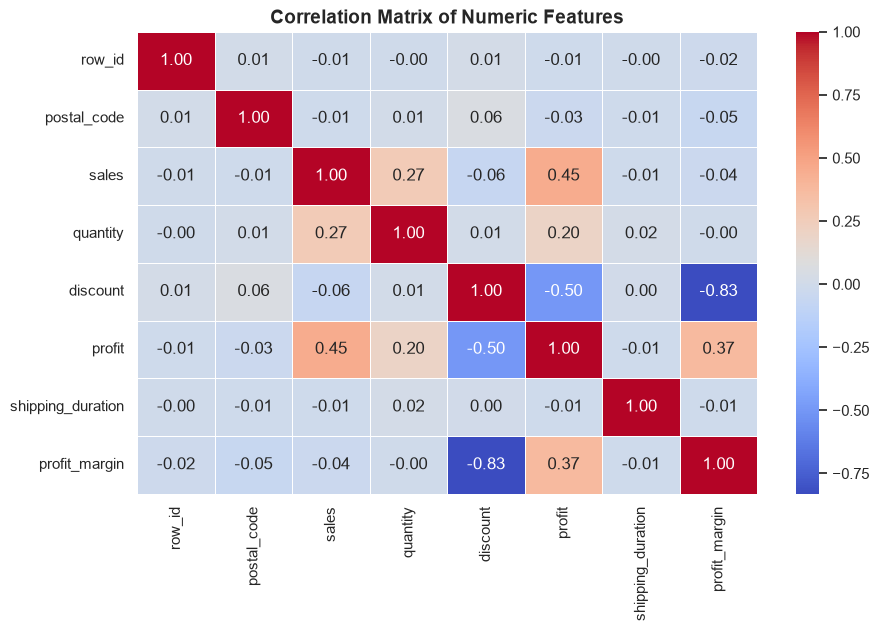

----- Generation Initial Visualizations ----- 


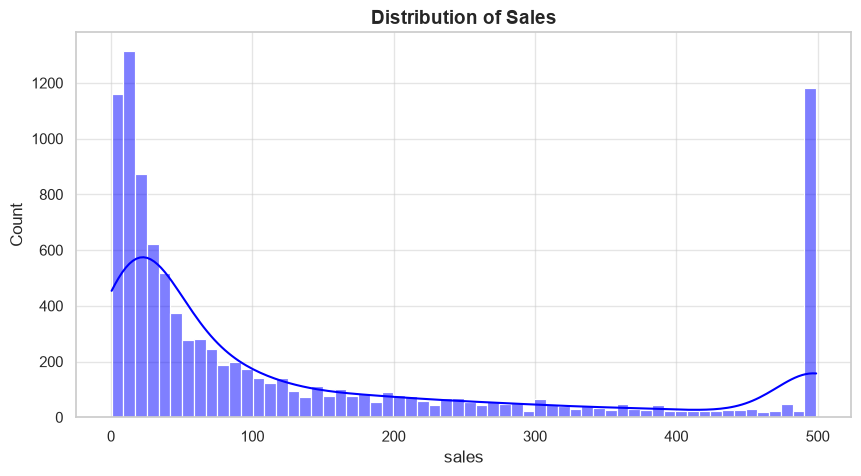

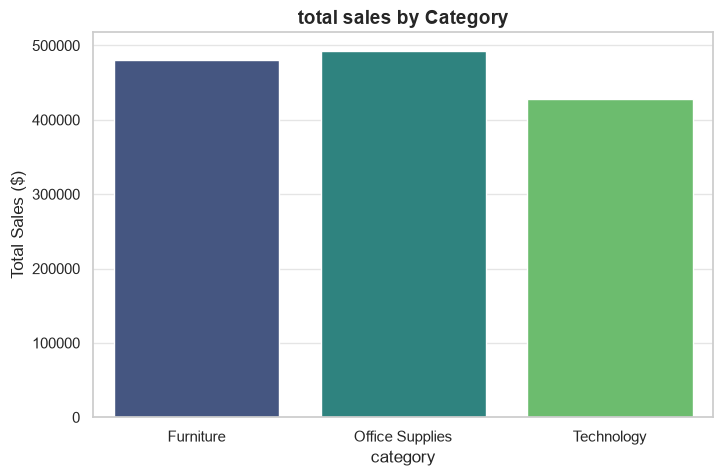

----- Generation Advanced Visualizations -----


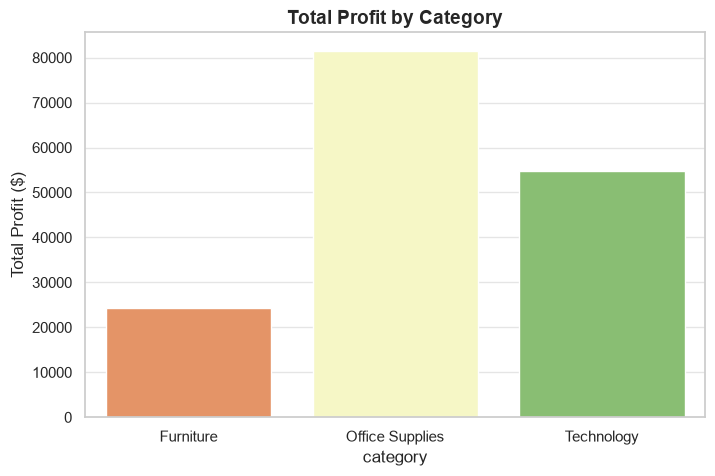

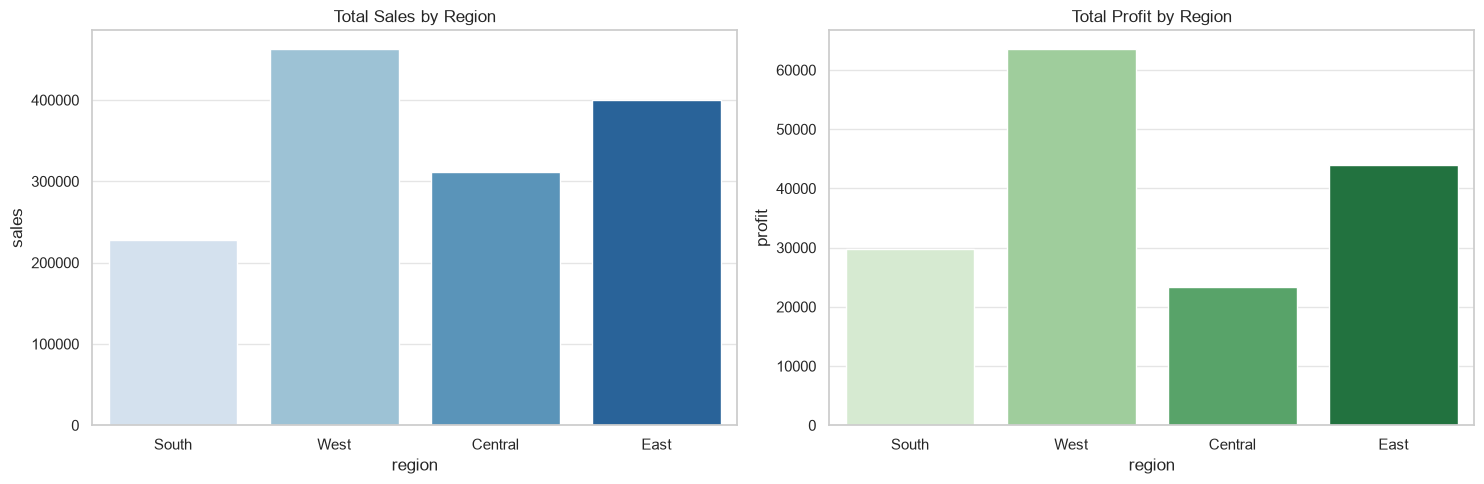

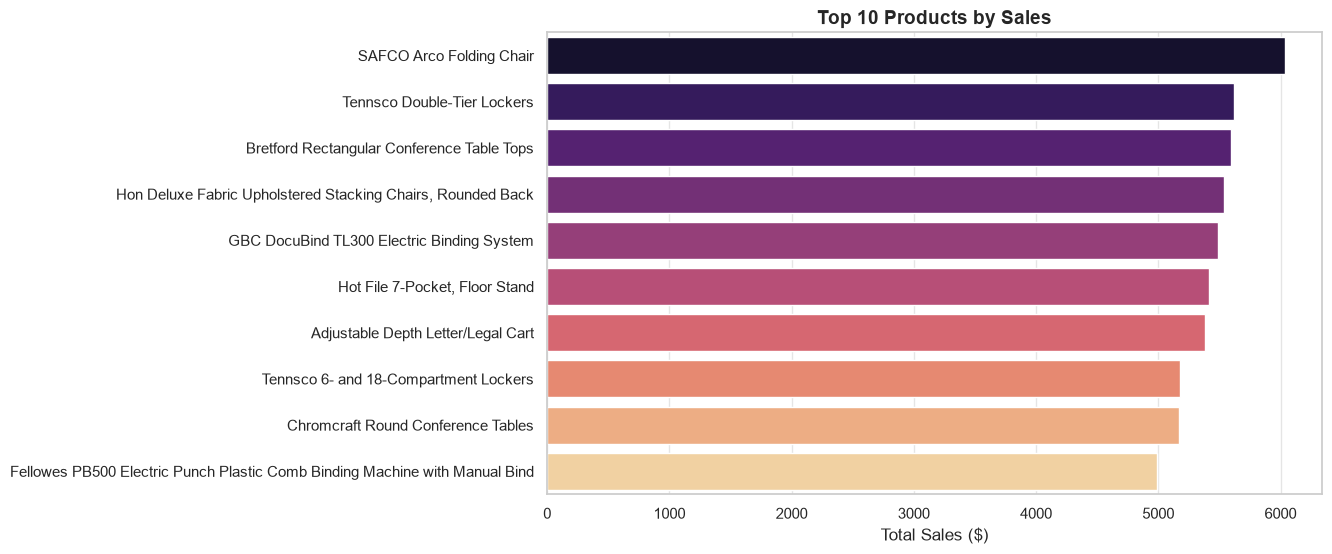

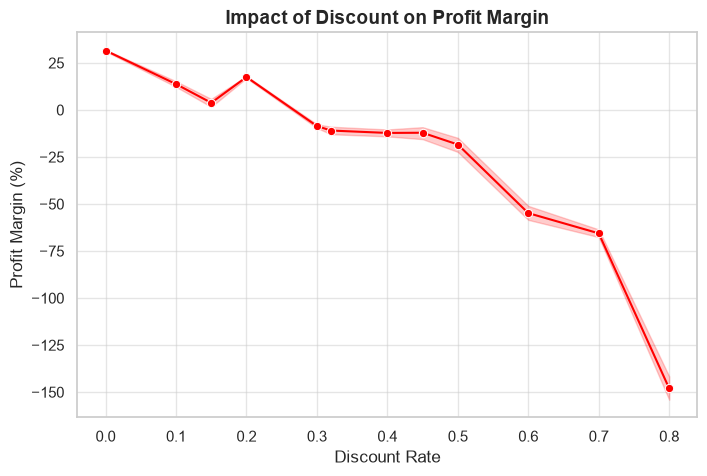

----- Generating Final Visualizations -----


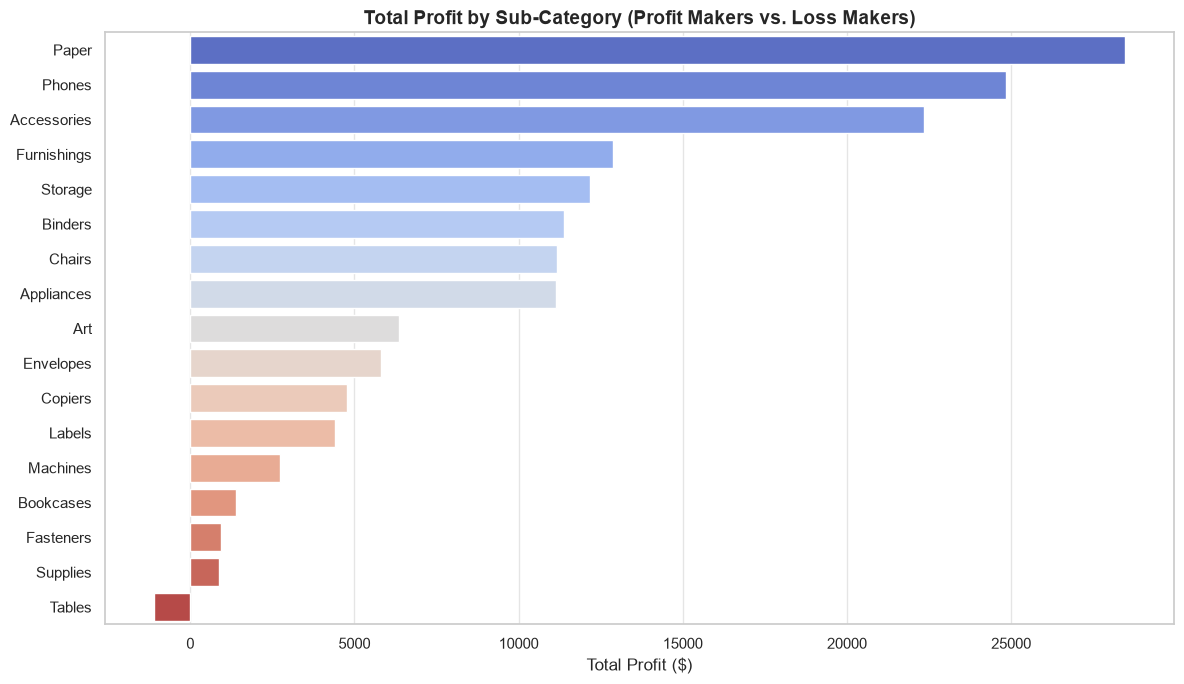

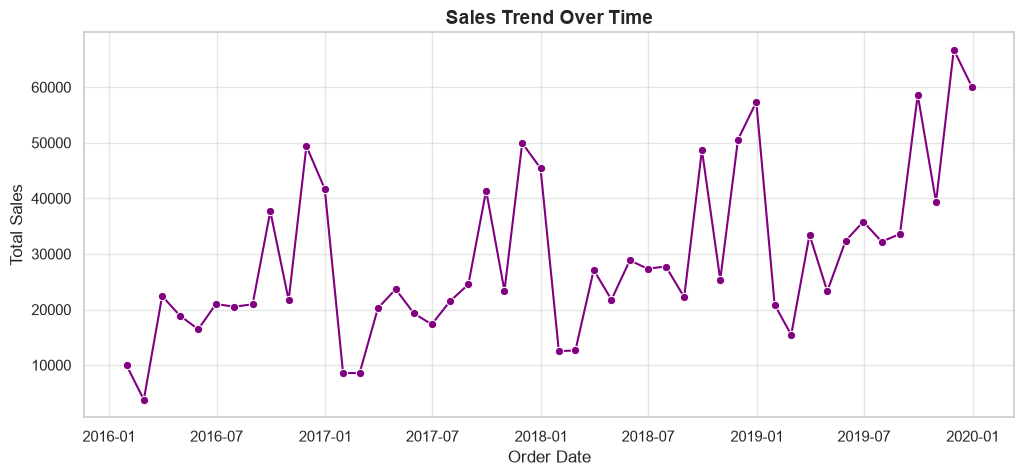

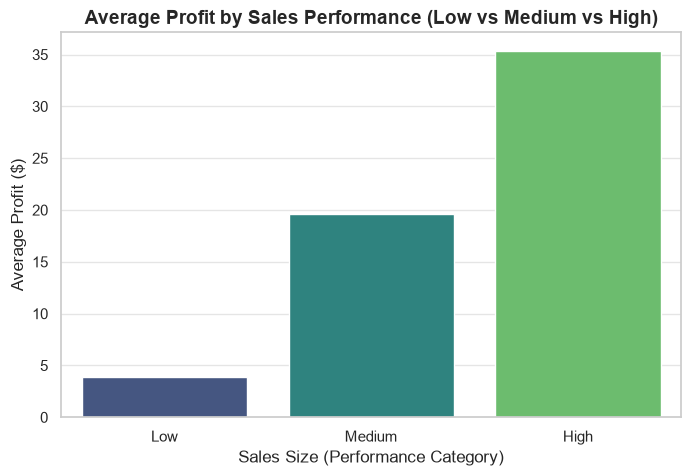

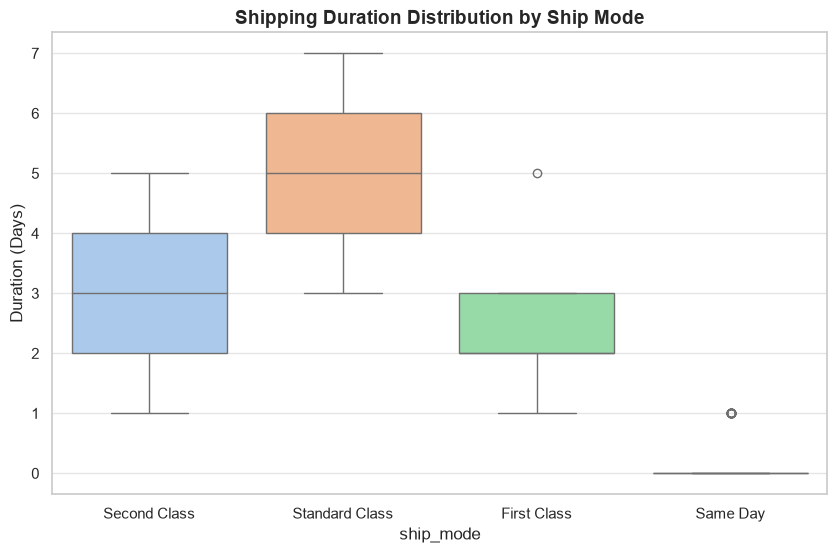

In [11]:
analyzer = EDA(final_df)
analyzer.perform_statistical_analysis()
analyzer.generate_initial_visualizations()
analyzer.generate_advanced_visualizations()
analyzer.generate_final_visualizations()

## Step 5: KPI Summary & Exporting
Finally, we generate an automated Executive Summary containing the core Business KPIs, and export the cleaned dataset for further reporting.

In [12]:
class KPIDashboard:
    def __init__(self,dataframe):
        self.df =dataframe.copy()

    def generate_summary(self):
        print("----- 📊 Executive KPI Summary -----")

        # Total Sales
        total_sales = self.df["sales"].sum()

        # Total Profit
        total_profit = self.df["profit"].sum()

        # Overall Margin
        overall_margin = (total_profit/total_sales)*100

        # Total Orders
        total_orders = self.df["order_id"].nunique()

        # AVG Shipping
        avg_shipping = self.df["shipping_duration"].mean()

        print(f"💰 Total Revenue (Sales) : ${total_sales:,.2f}")
        print(f"📈 Total Profit          : ${total_profit:,.2f}")
        print(f"🎯 Overall Profit Margin : {overall_margin:.2f}%")
        print(f"📦 Total Unique Orders   : {total_orders:,}")
        print(f"🚚 Avg Shipping Duration : {avg_shipping:.2f} Days")
        print("-" * 36 + "\n")

In [13]:
kpi_dashboard = KPIDashboard(final_df)
kpi_dashboard.generate_summary()

----- 📊 Executive KPI Summary -----
💰 Total Revenue (Sales) : $1,401,969.37
📈 Total Profit          : $160,583.73
🎯 Overall Profit Margin : 11.45%
📦 Total Unique Orders   : 5,009
🚚 Avg Shipping Duration : 3.96 Days
------------------------------------



In [14]:
class DataExporter:
    def __init__(self, dataframe):
        self.df = dataframe.copy()

    def save_to_csv(self, output_name="Cleaned_Superstore_Data.csv"):
        print("----- Starting Data Export -----")
        try:
            self.df.to_csv(output_name, index=False)
            print(f"Data successfully saved to {output_name}! ✅\n")
        except Exception as e:
            print(f"Error during export: {e}")

In [15]:
exporter = DataExporter(final_df)
exporter.save_to_csv("Cleaned_Superstore_Data.csv")

----- Starting Data Export -----
Data successfully saved to Cleaned_Superstore_Data.csv! ✅

